In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# import excel data
frames = []
for i in range(73):
    df_sheet = pd.read_excel(f"problematicData/diag_data{i}.xlsx")
    frames.append(df_sheet)

df = pd.concat(frames)
df

,Unnamed: 0,seed,col,n_nodes,n_nodes_used,is_regressor,unused_nodes,percentage,accuracy
0,0,0,0,1,1,False,0,0.000000,0.120000
1,1,0,1,23,23,True,0,0.000000,0.293356
2,2,0,2,27,27,False,0,0.000000,0.320000
3,3,0,3,29,29,True,0,0.000000,0.588977
4,4,0,4,31,31,False,0,0.000000,0.460000
...,...,...,...,...,...,...,...,...,...
96,96,72,96,31,17,False,14,45.161290,0.360000
97,97,72,97,21,21,True,0,0.000000,0.890816
98,98,72,98,31,24,False,7,22.580645,0.470000
99,99,72,99,31,31,True,0,0.000000,0.896546


([<matplotlib.patches.Wedge at 0x214893a86e0>,
 [Text(-0.01710713123828362, 1.0998669674377881, 'total regressors'),
  Text(0.017107096277351748, -1.0998669679815636, 'total classifiers')],
 [Text(-0.009331162493609246, 0.599927436784248, '50.5%'),
  Text(0.009331143424010044, -0.5999274370808527, '49.5%')])

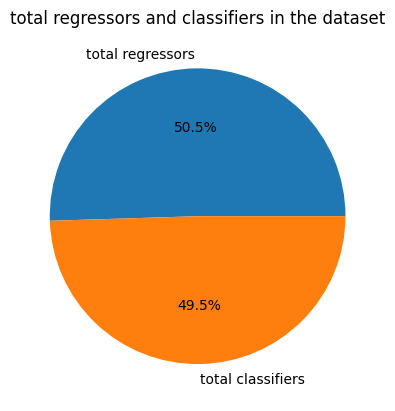

In [3]:
fig, ax = plt.subplots()
ax.set_title("total regressors and classifiers in the dataset")
n_reg = df["is_regressor"].sum()
n_clf = df.shape[0] -n_reg
sizes = [n_reg,n_clf]
labels = "total regressors","total classifiers"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')


In [4]:
m_clf = df["is_regressor"]==False
m_reg = df["is_regressor"]==True
m_no_target = df["col"] != "target"
m_has_difference = df["unused_nodes"] != 0

([<matplotlib.patches.Wedge at 0x21489412c10>,
 [Text(1.0994203173113914, 0.03570666440483502, 'total regressors'),
  Text(-1.0994203104653, -0.035706875197690474, 'total classifiers')],
 [Text(0.599683809442577, 0.019476362402637278, '1.0%'),
  Text(-0.5996838057083455, -0.019476477380558438, '99.0%')])

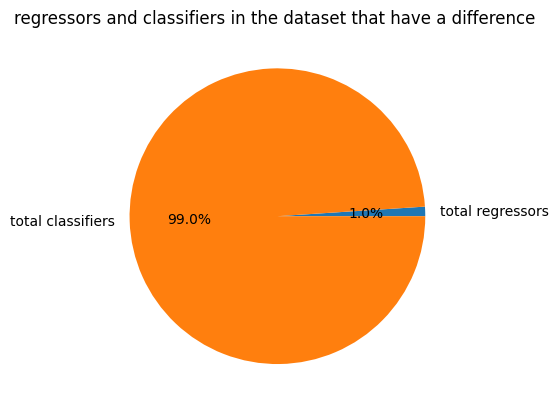

In [5]:
fig, ax = plt.subplots()
ax.set_title("regressors and classifiers in the dataset that have a difference ")
n_reg = df[m_has_difference]["is_regressor"].sum()
n_clf = df[m_has_difference].shape[0] -n_reg
sizes = [n_reg,n_clf]
labels = "total regressors","total classifiers"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')

In [6]:
df["has_difference"] = m_has_difference
df[["is_regressor","has_difference"]].value_counts(normalize=True)

is_regressor  has_difference
True          False             0.502645
False         False             0.274244
              True              0.220806
True          True              0.002306
Name: proportion, dtype: float64

([<matplotlib.patches.Wedge at 0x21489457390>,
 [Text(0.8406705599568358, 0.7094173733577861, 'not all nodes reached'),
  Text(-0.8406704133684378, -0.7094175470672685, 'all nodes reached')],
 [Text(0.458547578158274, 0.3869549309224287, '22.3%'),
  Text(-0.458547498200966, -0.38695502567305545, '77.7%')])

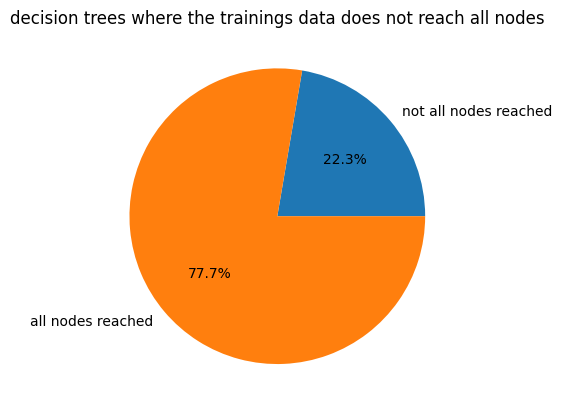

In [7]:
fig, ax = plt.subplots()
ax.set_title("decision trees where the trainings data does not reach all nodes")
n_has_diff = df["has_difference"].sum()
n_no_diff = df.shape[0] - n_has_diff
sizes = [n_has_diff,n_no_diff]
labels = "not all nodes reached","all nodes reached"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')

In [8]:
df[m_clf][["is_regressor","has_difference"]].value_counts(normalize=True)

is_regressor  has_difference
False         False             0.553973
              True              0.446027
Name: proportion, dtype: float64

In [9]:
df[m_reg][["is_regressor","has_difference"]].value_counts(normalize=False)

is_regressor  has_difference
True          False             3706
              True                17
Name: count, dtype: int64

In [10]:
df[m_reg][["is_regressor","has_difference"]].value_counts(normalize=True)*100

is_regressor  has_difference
True          False             99.543379
              True               0.456621
Name: proportion, dtype: float64

<Axes: xlabel='col', ylabel='unused_nodes'>

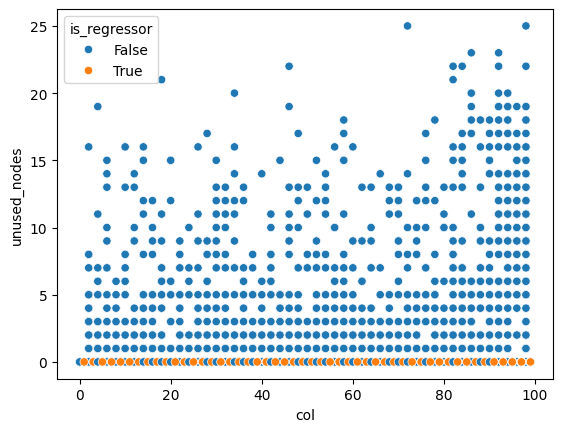

In [11]:
sns.scatterplot(data=df[m_no_target],x="col",y="unused_nodes",hue="is_regressor")

([<matplotlib.patches.Wedge at 0x2148956d810>,
 [Text(0.8185143098971264, 0.734870277323577, 'not all nodes reached'),
  Text(-0.8185140266442538, -0.7348705928165924, 'all nodes reached')],
 [Text(0.446462350852978, 0.4008383330855874, '23.3%'),
  Text(-0.4464621963514111, -0.40083850517268677, '76.7%')])

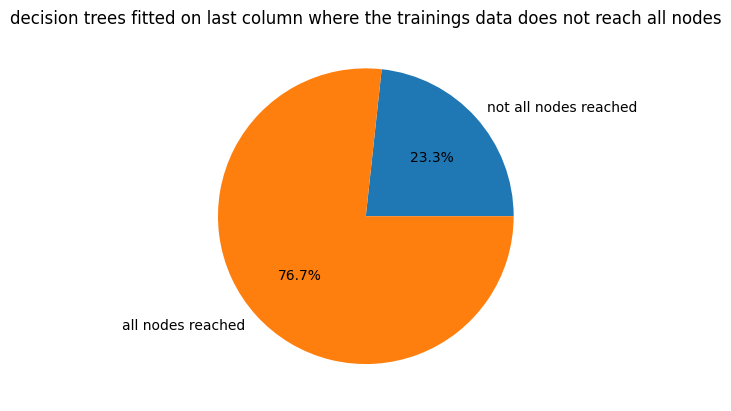

In [12]:
#sns.scatterplot(data=df[m_no_target & m_reg],x="col",y="unused_nodes")

fig, ax = plt.subplots()
ax.set_title("decision trees fitted on last column where the trainings data does not reach all nodes")
n_has_diff = df[~m_no_target]["has_difference"].sum()
n_no_diff = df[~m_no_target].shape[0] - n_has_diff
sizes = [n_has_diff,n_no_diff]
labels = "not all nodes reached","all nodes reached"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x21489501310>,
 [Text(0.18562344741145728, 1.084225039265874, 'not all nodes reached'),
  Text(-0.18562348187518674, -1.084225033365552, 'all nodes reached')],
 [Text(0.10124915313352215, 0.591395475963204, '44.6%'),
  Text(-0.10124917193192003, -0.5913954727448465, '55.4%')])

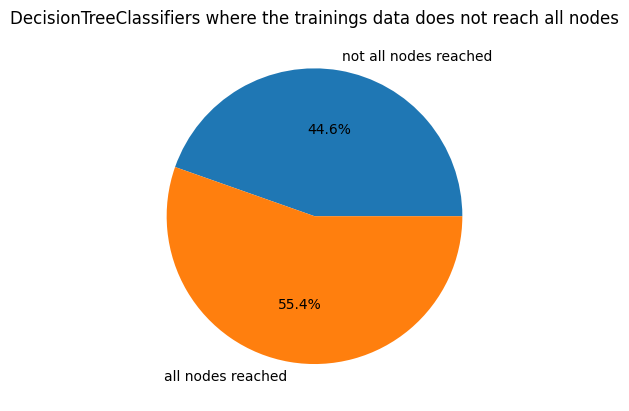

In [13]:
fig, ax = plt.subplots()
ax.set_title("DecisionTreeClassifiers where the trainings data does not reach all nodes")
n_has_diff = df[~m_reg]["has_difference"].sum()
n_no_diff = df[~m_reg].shape[0] - n_has_diff
sizes = [n_has_diff,n_no_diff]
labels = "not all nodes reached","all nodes reached"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')

<Axes: xlabel='percentage', ylabel='accuracy'>

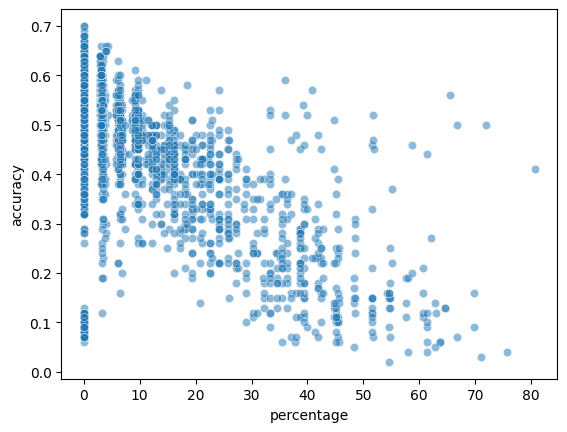

In [14]:
sns.scatterplot(data=df[~m_reg],x="percentage",y="accuracy",alpha=0.5)

<Axes: xlabel='unused_nodes', ylabel='accuracy'>

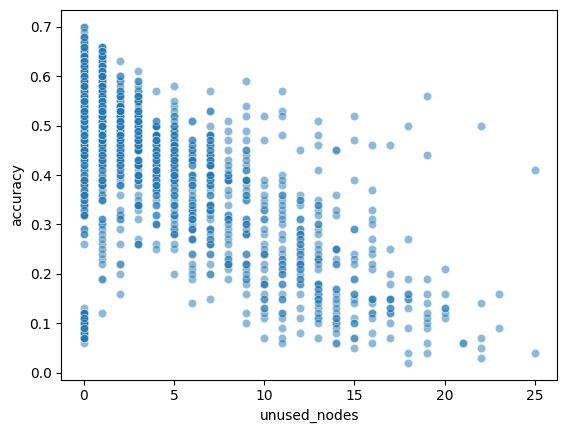

In [15]:
sns.scatterplot(data=df[~m_reg],x="unused_nodes",y="accuracy",alpha=0.5)

In [16]:
#sns.scatterplot(data=df[m_reg],x="percentage",y="accuracy",alpha=0.5)

<Axes: xlabel='has_difference', ylabel='accuracy'>

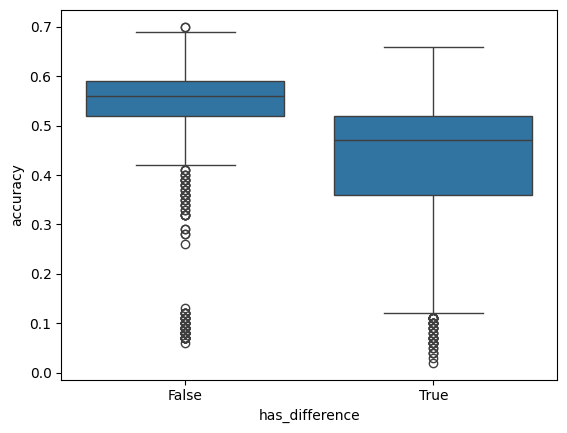

In [17]:
sns.boxplot(data =df[~m_reg],x="has_difference",y="accuracy")

<Axes: xlabel='accuracy', ylabel='Count'>

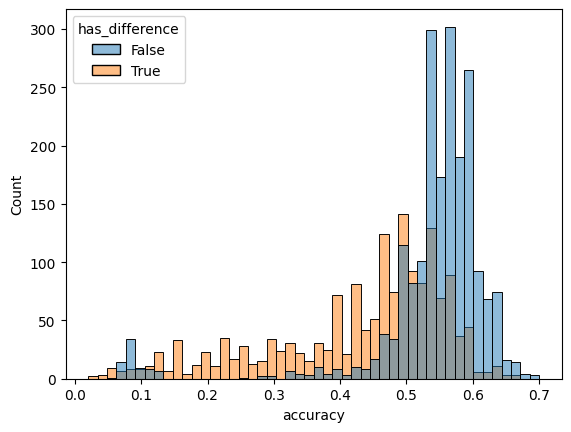

In [18]:
sns.histplot(data =df[~m_reg],x="accuracy",hue="has_difference")

<Axes: xlabel='accuracy', ylabel='Count'>

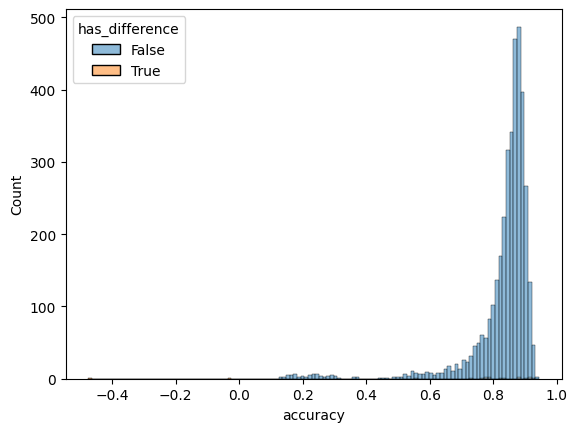

In [19]:
sns.histplot(data =df[m_reg],x="accuracy",hue="has_difference")